<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/integrated_sil_esd_hipps_depressurization_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrated SIL, ESD, HIPPS, and depressurization safety study

This notebook connects an overpressure scenario across LOPA and SIL
determination, HIPPS architecture, ESD response time, process pressure
transients, cold and fire depressurization, and simultaneous flare-header load.

It is an educational screening example, not an approved LOPA, SRS, HIPPS design,
PSV sizing, flare study, fire analysis, metallurgy assessment, or functional
safety verification. Independent engineering review and project-specific data
remain mandatory.

## Learning objectives

After completing the notebook, you can:

1. derive a target risk-reduction factor from a LOPA scenario;
2. calculate a HIPPS average probability of failure on demand;
3. test proof-interval sensitivity and 2oo3 voting behavior;
4. compare ESD/HIPPS response time with process safety time;
5. simulate pressure rise during delayed valve closure;
6. screen cold and fire depressurization cases;
7. combine blowdown sources and check flare-header Mach number.

## Study logic and equations

For independent protection layers with average failure probabilities
$\mathrm{PFD}_i$, the mitigated frequency is:

$$
f_{\mathrm{mitigated}}
  = f_{\mathrm{initiating}}\prod_i \mathrm{PFD}_i
$$

A screening HIPPS total is formed from sensor, logic-solver, final-element,
and explicit common-cause contributions:

$$
\mathrm{PFD}_{\mathrm{HIPPS}}
  = \mathrm{PFD}_{2oo3,s}
  + \beta_s\frac{\lambda_{DU,s}T}{2}
  + \mathrm{PFD}_{1oo1,l}
  + \mathrm{PFD}_{1oo2,v}
  + \beta_v\frac{\lambda_{DU,v}T}{2}
$$

Functional success also requires:

$$
t_{\mathrm{detect}}+t_{\mathrm{logic}}+t_{\mathrm{close}}
  < t_{\mathrm{process\ safety}}
$$

Depressurization couples mass and energy balances. The NeqSim simulator updates
real-gas state, choked/subcritical flow, fluid temperature, and a lumped wall
temperature through the transient.

## Standards context

IEC 61511-1 defines safety-lifecycle requirements for process-sector SIS.
IEC 61511-3 provides guidance for hazard/risk assessment and required SIL
determination. ISO 23251 covers pressure-relieving and depressuring systems for
petroleum, petrochemical, and natural-gas industries.

The frequencies, failure rates, beta factors, response times, fire exposure, and
acceptance criteria below are synthetic. Replace them with approved project data
and lifecycle assumptions.

In [1]:
%pip install -q "neqsim==3.16.0" "pandas>=2.2" "matplotlib>=3.8"

## Imports and runtime evidence

In [2]:
import hashlib
import importlib.metadata
import json
import platform
import sys
from pathlib import Path
from xml.etree import ElementTree as ET

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))

,version
neqsim,3.16.0
python,3.12.13
java,17.0.19
numpy,2.5.1
pandas,3.0.5
matplotlib,3.11.1


## Design basis and protected process

In [3]:
design_basis = pd.DataFrame(
    [
        ["Feed flow", 60_000.0, "kg/h"],
        ["Upstream pressure", 90.0, "bara"],
        ["Normal protected pressure", 75.0, "bara"],
        ["HIPPS trip pressure", 82.0, "bara"],
        ["HIPPS study start pressure", 85.0, "bara"],
        ["Protected volume", 80.0, "m³"],
        ["MAWP", 100.0, "bara"],
        ["Cold blowdown stop pressure", 8.0, "bara"],
        ["Flare backpressure", 1.5, "bara"],
        ["Maximum flare-header Mach", 0.70, "-"],
    ],
    columns=["Parameter", "Value", "Unit"],
)
display(design_basis)

,Parameter,Value,Unit
0,Feed flow,60000.0,kg/h
1,Upstream pressure,90.0,bara
2,Normal protected pressure,75.0,bara
3,HIPPS trip pressure,82.0,bara
4,HIPPS study start pressure,85.0,bara
5,Protected volume,80.0,m³
6,MAWP,100.0,bara
7,Cold blowdown stop pressure,8.0,bara
8,Flare backpressure,1.5,bara
9,Maximum flare-header Mach,0.7,-


In [4]:
components = [
    ("nitrogen", 0.010),
    ("CO2", 0.020),
    ("methane", 0.860),
    ("ethane", 0.070),
    ("propane", 0.040),
]

fluid = ns.thermo.system.SystemSrkEos(308.15, 90.0)
for component, mole_fraction in components:
    fluid.addComponent(component, mole_fraction)
fluid.createDatabase(True)
fluid.setMixingRule(2)
fluid.setMultiPhaseCheck(True)

feed = ns.process.equipment.stream.Stream("Feed-101", fluid)
feed.setFlowRate(60_000.0, "kg/hr")

hipps_xv_a = ns.process.equipment.valve.HIPPSValve("HIPPS-XV-101A", feed)
hipps_xv_a.setOutletPressure(75.0, "bara")
hipps_xv_a.setClosureTime(6.0)
hipps_xv_a.setSILRating(3)
hipps_xv_a.setProofTestInterval(8760.0)
hipps_xv_a.setVotingLogic(
    ns.process.equipment.valve.HIPPSValve.VotingLogic.TWO_OUT_OF_THREE
)

hipps_xv_b = ns.process.equipment.valve.HIPPSValve(
    "HIPPS-XV-101B",
    hipps_xv_a.getOutletStream(),
)
hipps_xv_b.setOutletPressure(75.0, "bara")
hipps_xv_b.setClosureTime(6.0)
hipps_xv_b.setSILRating(3)

separator = ns.process.equipment.separator.Separator(
    "V-101 HP Separator",
    hipps_xv_b.getOutletStream(),
)
compressor = ns.process.equipment.compressor.Compressor(
    "K-101 Export Compressor",
    separator.getGasOutStream(),
)
compressor.setOutletPressure(105.0, "bara")
compressor.setIsentropicEfficiency(0.75)

aftercooler = ns.process.equipment.heatexchanger.Cooler(
    "E-101 Export Aftercooler",
    compressor.getOutletStream(),
)
aftercooler.setOutTemperature(313.15)

process = ns.process.processmodel.ProcessSystem()
for unit in [
    feed,
    hipps_xv_a,
    hipps_xv_b,
    separator,
    compressor,
    aftercooler,
]:
    process.add(unit)
process.run()

In [5]:
gas_out = separator.getGasOutStream()
mass_in = float(feed.getFlowRate("kg/hr"))
gas_mass = float(gas_out.getFlowRate("kg/hr"))
liquid_mass = float(separator.getLiquidOutStream().getFlowRate("kg/hr"))
process_results = pd.DataFrame(
    [
        ["Feed mass flow", mass_in, "kg/h"],
        ["Separator gas flow", gas_mass, "kg/h"],
        ["Separator liquid flow", liquid_mass, "kg/h"],
        ["Separator gas pressure", gas_out.getPressure("bara"), "bara"],
        ["Separator gas temperature", gas_out.getTemperature("C"), "°C"],
        [
            "Mass-balance relative error",
            abs(mass_in - gas_mass - liquid_mass) / mass_in,
            "-",
        ],
    ],
    columns=["Result", "Value", "Unit"],
)
display(process_results)

,Result,Value,Unit
0,Feed mass flow,6.000000e+04,kg/h
1,Separator gas flow,6.000000e+04,kg/h
2,Separator liquid flow,1.800000e-25,kg/h
3,Separator gas pressure,7.500000e+01,bara
4,Separator gas temperature,2.894347e+01,°C
5,Mass-balance relative error,3.000000e-30,-


## Barrier architecture

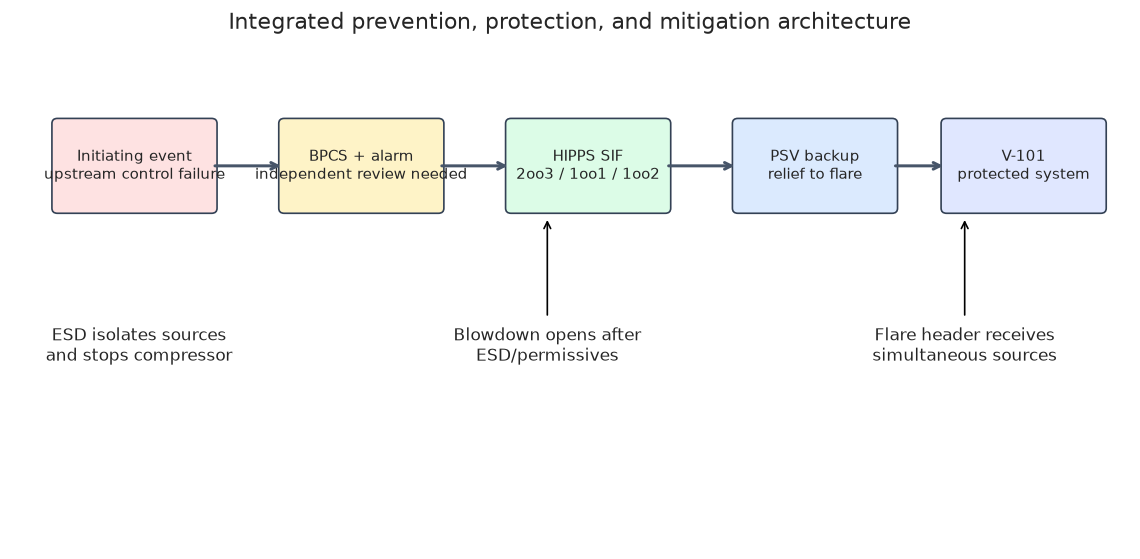

In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0, 12.3)
ax.set_ylim(0, 6)
ax.axis("off")

layers = [
    (0.5, 4.0, "Initiating event\nupstream control failure", "#fee2e2"),
    (3.0, 4.0, "BPCS + alarm\nindependent review needed", "#fef3c7"),
    (5.5, 4.0, "HIPPS SIF\n2oo3 / 1oo1 / 1oo2", "#dcfce7"),
    (8.0, 4.0, "PSV backup\nrelief to flare", "#dbeafe"),
    (10.3, 4.0, "V-101\nprotected system", "#e0e7ff"),
]
for x, y, label, color in layers:
    box = patches.FancyBboxPatch(
        (x, y),
        1.7,
        1.0,
        boxstyle="round,pad=0.06",
        facecolor=color,
        edgecolor="#334155",
    )
    ax.add_patch(box)
    ax.text(x + 0.85, y + 0.5, label, ha="center", va="center", fontsize=9)
for x0, x1 in [(2.2, 3.0), (4.7, 5.5), (7.2, 8.0), (9.7, 10.3)]:
    ax.annotate(
        "",
        xy=(x1, 4.5),
        xytext=(x0, 4.5),
        arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#475569"},
    )

ax.text(1.4, 2.2, "ESD isolates sources\nand stops compressor", ha="center")
ax.text(5.9, 2.2, "Blowdown opens after\nESD/permissives", ha="center")
ax.text(10.5, 2.2, "Flare header receives\nsimultaneous sources", ha="center")
ax.annotate("", xy=(5.9, 3.9), xytext=(5.9, 2.7), arrowprops={"arrowstyle": "->"})
ax.annotate("", xy=(10.5, 3.9), xytext=(10.5, 2.7), arrowprops={"arrowstyle": "->"})
ax.set_title("Integrated prevention, protection, and mitigation architecture")
plt.show()

## Real-gas inventory and process safety time

A pressure-density grid at the separator gas temperature converts continuing
inflow into pressure rise. For fixed gas volume $V$:

$$
\frac{dP}{dt}
  = \frac{\dot m_{\mathrm{in}}}
         {V\,d\rho/dP}
$$

This is a deliberately transparent screening transient. A detailed project model
should include upstream hydraulics, valve characteristics, vessel holdup,
heat transfer, and PSV interaction.

In [7]:
gas_template = gas_out.getThermoSystem().clone()
gas_temperature_k = float(gas_out.getTemperature("K"))
pressure_grid = np.linspace(75.0, 105.0, 61)
density_grid = []
for pressure in pressure_grid:
    state = gas_template.clone()
    state.setTemperature(gas_temperature_k)
    state.setPressure(float(pressure))
    operations = ns.thermodynamicoperations.ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    density_grid.append(float(state.getDensity("kg/m3")))
density_grid = np.array(density_grid)

protected_volume_m3 = 80.0
inflow_kg_s = mass_in / 3600.0
rho_pshh = np.interp(82.0, pressure_grid, density_grid)
rho_mawp = np.interp(100.0, pressure_grid, density_grid)
process_safety_time_s = (
    protected_volume_m3 * (rho_mawp - rho_pshh) / inflow_kg_s
)

density_evidence = pd.DataFrame(
    {
        "Pressure (bara)": pressure_grid[::10],
        "Density (kg/m³)": density_grid[::10],
    }
)
display(density_evidence)
display(
    pd.DataFrame(
        [
            ["Process safety time from 82 to 100 bara", process_safety_time_s, "s"],
            ["Continuing inflow", inflow_kg_s, "kg/s"],
            ["Protected volume", protected_volume_m3, "m³"],
        ],
        columns=["Metric", "Value", "Unit"],
    )
)

,Pressure (bara),Density (kg/m³)
0,75.0,66.326447
1,80.0,71.421213
2,85.0,76.573882
3,90.0,81.775056
4,95.0,87.014325
5,100.0,92.280420
6,105.0,97.561405


,Metric,Value,Unit
0,Process safety time from 82 to 100 bara,90.262008,s
1,Continuing inflow,16.666667,kg/s
2,Protected volume,80.000000,m³


## LOPA and SIL target

In [8]:
initiating_frequency = 0.1
bpcs_pfd = 0.1
alarm_operator_pfd = 0.1
target_frequency = 1.0e-6

lopa = ns.process.safety.risk.sis.LOPAResult(
    "V-101 overpressure from upstream control failure"
)
lopa.setInitiatingEventFrequency(initiating_frequency)
lopa.setTargetFrequency(target_frequency)
after_bpcs = initiating_frequency * bpcs_pfd
after_alarm = after_bpcs * alarm_operator_pfd
lopa.addLayer("BPCS pressure control", bpcs_pfd, initiating_frequency, after_bpcs)
lopa.addLayer(
    "Independent alarm and operator action",
    alarm_operator_pfd,
    after_bpcs,
    after_alarm,
)
lopa.setMitigatedFrequency(after_alarm)

lopa_summary = pd.DataFrame(
    [
        ["Initiating frequency", initiating_frequency, "per year"],
        ["After BPCS", after_bpcs, "per year"],
        ["After alarm/operator", after_alarm, "per year"],
        ["Target frequency", target_frequency, "per year"],
        ["Additional RRF required", lopa.getRequiredAdditionalRRF(), "-"],
        ["Additional SIL required", lopa.getRequiredAdditionalSIL(), "-"],
    ],
    columns=["Metric", "Value", "Unit"],
)
display(lopa_summary)

,Metric,Value,Unit
0,Initiating frequency,0.100000,per year
1,After BPCS,0.010000,per year
2,After alarm/operator,0.001000,per year
3,Target frequency,0.000001,per year
4,Additional RRF required,1000.000000,-
5,Additional SIL required,3.000000,-


## HIPPS PFD calculation and native SIL verification

In [9]:
sif_class = ns.process.safety.risk.sis.SafetyInstrumentedFunction
test_interval_h = 8760.0
sensor_lambda_du_h = 2.0e-6
logic_lambda_du_h = 0.05e-6
valve_lambda_du_h = 1.0e-6
sensor_beta = 0.02
valve_beta = 0.02

pfd_sensor_independent = float(
    sif_class.calculatePfd2oo3(sensor_lambda_du_h, test_interval_h)
)
pfd_sensor_common = sensor_beta * sensor_lambda_du_h * test_interval_h / 2.0
pfd_logic = float(
    sif_class.calculatePfd1oo1(logic_lambda_du_h, test_interval_h)
)
pfd_valve_independent = float(
    sif_class.calculatePfd1oo2(valve_lambda_du_h, test_interval_h)
)
pfd_valve_common = valve_beta * valve_lambda_du_h * test_interval_h / 2.0
hipps_pfd = sum(
    [
        pfd_sensor_independent,
        pfd_sensor_common,
        pfd_logic,
        pfd_valve_independent,
        pfd_valve_common,
    ]
)

hipps_sif = sif_class("SIF-HIPPS-101", 3, hipps_pfd)
hipps_sif.setCategory(sif_class.SIFCategory.HIPPS)
hipps_sif.setArchitecture("2oo3 sensors + 1oo1 logic + 1oo2 valves")
hipps_sif.setSafeState("HIPPS-XV-101A/B closed")
hipps_sif.setTestIntervalHours(test_interval_h)
hipps_sif.addProtectedEquipment("V-101")
verification = ns.process.safety.risk.sis.SILVerificationResult(hipps_sif)
verification.addComponentContribution(
    "Sensors",
    "2oo3 plus beta",
    pfd_sensor_independent + pfd_sensor_common,
    sensor_lambda_du_h,
    test_interval_h,
)
verification.addComponentContribution(
    "Logic solver",
    "1oo1",
    pfd_logic,
    logic_lambda_du_h,
    test_interval_h,
)
verification.addComponentContribution(
    "Final elements",
    "1oo2 plus beta",
    pfd_valve_independent + pfd_valve_common,
    valve_lambda_du_h,
    test_interval_h,
)

residual_frequency = after_alarm * hipps_pfd
pfd_contributions = pd.DataFrame(
    [
        ["Sensors: independent 2oo3", pfd_sensor_independent],
        ["Sensors: beta common cause", pfd_sensor_common],
        ["Logic solver: 1oo1", pfd_logic],
        ["Valves: independent 1oo2", pfd_valve_independent],
        ["Valves: beta common cause", pfd_valve_common],
        ["Total HIPPS", hipps_pfd],
    ],
    columns=["Contribution", "PFDavg"],
)
display(pfd_contributions.style.format({"PFDavg": "{:.3e}"}))
display(
    pd.DataFrame(
        [
            ["Required SIL", lopa.getRequiredAdditionalSIL()],
            ["Achieved SIL", verification.getAchievedSIL()],
            ["Residual frequency per year", residual_frequency],
            ["Target met", residual_frequency <= target_frequency],
        ],
        columns=["Verification", "Value"],
    )
)

,Contribution,PFDavg
0,Sensors: independent 2oo3,3.070e-04
1,Sensors: beta common cause,1.752e-04
2,Logic solver: 1oo1,2.190e-04
3,Valves: independent 1oo2,2.558e-05
4,Valves: beta common cause,8.760e-05
5,Total HIPPS,8.143e-04


,Verification,Value
0,Required SIL,3
1,Achieved SIL,3
2,Residual frequency per year,0.000001
3,Target met,True


## Proof-test interval sensitivity

,Proof interval (years),HIPPS PFDavg,Residual frequency (/y),SIL 3 PFD band
0,0.250000,1.412e-04,1.412e-07,True
1,0.500000,3.240e-04,3.240e-07,True
2,1.000000,8.143e-04,8.143e-07,True
3,1.500000,1.471e-03,1.471e-06,False
4,2.000000,2.294e-03,2.294e-06,False


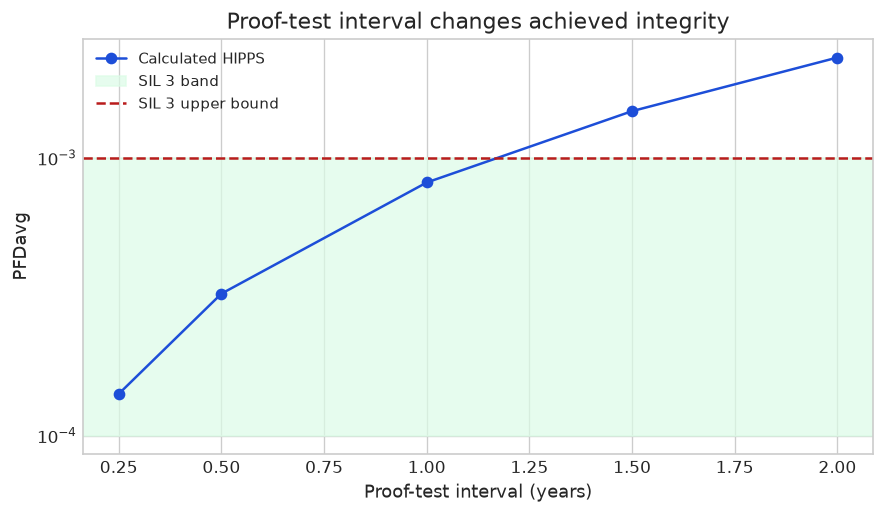

In [10]:
interval_years = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
sensitivity_rows = []
for years in interval_years:
    interval_h = years * 8760.0
    sensor_ind = float(
        sif_class.calculatePfd2oo3(sensor_lambda_du_h, interval_h)
    )
    sensor_ccf = sensor_beta * sensor_lambda_du_h * interval_h / 2.0
    logic = float(
        sif_class.calculatePfd1oo1(logic_lambda_du_h, interval_h)
    )
    valve_ind = float(
        sif_class.calculatePfd1oo2(valve_lambda_du_h, interval_h)
    )
    valve_ccf = valve_beta * valve_lambda_du_h * interval_h / 2.0
    total = sensor_ind + sensor_ccf + logic + valve_ind + valve_ccf
    sensitivity_rows.append(
        [years, total, after_alarm * total, total < 1.0e-3]
    )
proof_sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "Proof interval (years)",
        "HIPPS PFDavg",
        "Residual frequency (/y)",
        "SIL 3 PFD band",
    ],
)
display(
    proof_sensitivity.style.format(
        {
            "HIPPS PFDavg": "{:.3e}",
            "Residual frequency (/y)": "{:.3e}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.semilogy(
    proof_sensitivity["Proof interval (years)"],
    proof_sensitivity["HIPPS PFDavg"],
    marker="o",
    color="#1d4ed8",
    label="Calculated HIPPS",
)
ax.axhspan(1.0e-4, 1.0e-3, color="#dcfce7", alpha=0.7, label="SIL 3 band")
ax.axhline(1.0e-3, color="#b91c1c", linestyle="--", label="SIL 3 upper bound")
ax.set_xlabel("Proof-test interval (years)")
ax.set_ylabel("PFDavg")
ax.set_title("Proof-test interval changes achieved integrity")
ax.legend()
plt.show()

## 2oo3 sensing and degraded-state truth table

In [11]:
hipps_xv_a.setVotingLogic(
    ns.process.equipment.valve.HIPPSValve.VotingLogic.TWO_OUT_OF_THREE
)
voting_rows = []
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            votes = a + b + c
            voting_rows.append(
                [a, b, c, votes, votes >= 2, "Trip" if votes >= 2 else "No trip"]
            )
voting_table = pd.DataFrame(
    voting_rows,
    columns=["PSHH-A", "PSHH-B", "PSHH-C", "Votes", "2oo3 result", "Action"],
)
display(voting_table)
display(
    pd.DataFrame(
        [
            ["Configured voting", str(hipps_xv_a.getVotingLogic())],
            ["SIL rating", hipps_xv_a.getSILRating()],
            ["Closure time", hipps_xv_a.getClosureTime()],
            ["Proof-test interval", hipps_xv_a.getProofTestInterval()],
        ],
        columns=["Native HIPPS property", "Value"],
    )
)

,PSHH-A,PSHH-B,PSHH-C,Votes,2oo3 result,Action
0,0,0,0,0,False,No trip
1,0,0,1,1,False,No trip
2,0,1,0,1,False,No trip
3,0,1,1,2,True,Trip
4,1,0,0,1,False,No trip
5,1,0,1,2,True,Trip
6,1,1,0,2,True,Trip
7,1,1,1,3,True,Trip


,Native HIPPS property,Value
0,Configured voting,TWO_OUT_OF_THREE
1,SIL rating,3
2,Closure time,6.0
3,Proof-test interval,8760.0


## ESD/HIPPS response-time budget

In [12]:
esd_cases = [
    ["Healthy", 0.8, 0.4, 6.0, 0.9],
    ["One sensor unavailable", 1.2, 0.4, 6.0, 0.9],
    ["Degraded actuator", 0.8, 0.4, 25.0, 0.9],
]
response_rows = []
for name, detection_s, logic_s, stroke_s, lag_s in esd_cases:
    simulator = ns.process.safety.esd.EsdResponseTimeSimulator()
    simulator.setSifTag("SIF-HIPPS-101")
    simulator.addDetection("2oo3 pressure detection", detection_s)
    simulator.addLogic("SIS logic solver", logic_s)
    simulator.addValve("HIPPS final elements", stroke_s, lag_s)
    simulator.setAllowableResponseTimeS(process_safety_time_s)
    result = simulator.evaluate()
    response_rows.append(
        [
            name,
            result.getDetectionTimeS(),
            result.getLogicTimeS(),
            result.getFinalElementTimeS(),
            result.getTotalResponseTimeS(),
            result.getMarginS(),
            result.isWithinBudget(),
        ]
    )
response_table = pd.DataFrame(
    response_rows,
    columns=[
        "Case",
        "Detection (s)",
        "Logic (s)",
        "Final element (s)",
        "Total (s)",
        "Margin to PST (s)",
        "Within PST",
    ],
)
display(response_table)

,Case,Detection (s),Logic (s),Final element (s),Total (s),Margin to PST (s),Within PST
0,Healthy,0.8,0.4,6.9,8.1,82.162008,True
1,One sensor unavailable,1.2,0.4,6.9,8.5,81.762008,True
2,Degraded actuator,0.8,0.4,25.9,27.1,63.162008,True


## Pressure rise during HIPPS closure

Passing the response-time inequality is necessary but not sufficient. The
transient also checks maximum pressure while valve opening falls linearly.
The unavailable case keeps full inflow and demonstrates why a conventional PSV
remains an independent backup.

,Case,Maximum pressure (bara),Time to MAWP (s),Below MAWP
0,Healthy 2oo3,82.839062,NaN,True
1,One sensor unavailable,82.919859,NaN,True
2,Degraded actuator,84.754467,NaN,True
3,HIPPS unavailable,111.779510,90.3,False


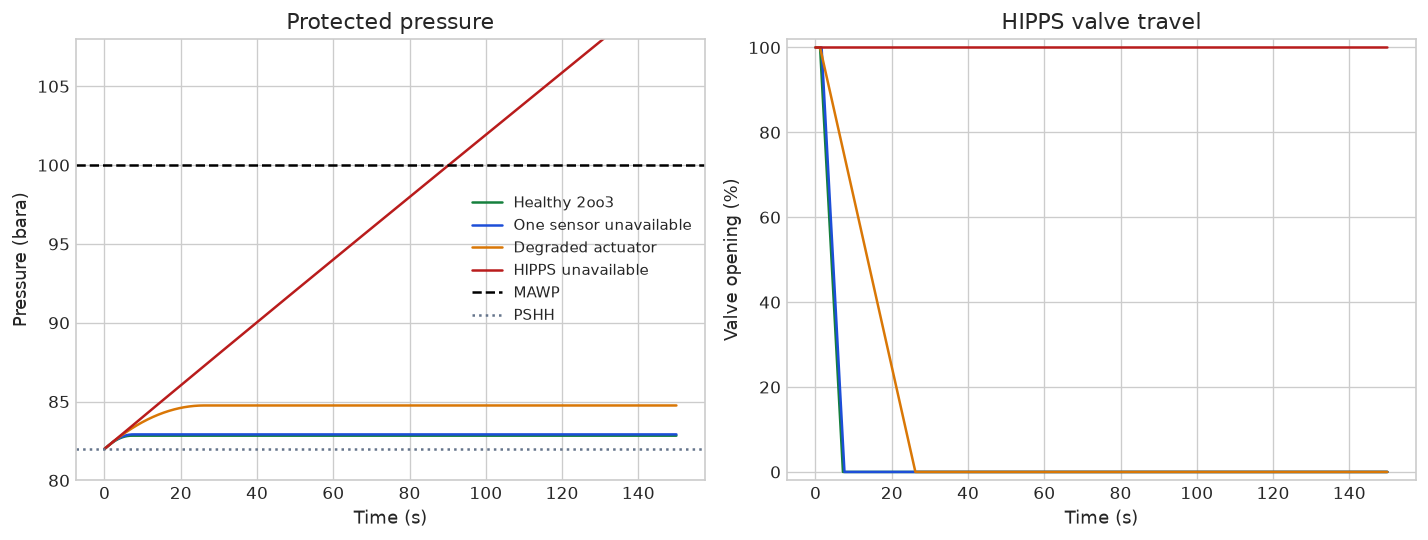

In [13]:
drho_dp_grid = np.gradient(density_grid, pressure_grid)


def simulate_pressure_case(name, detect_s, close_s, available=True):
    dt = 0.1
    time = np.arange(0.0, 150.0 + dt, dt)
    pressure = np.zeros_like(time)
    opening = np.ones_like(time)
    pressure[0] = 82.0
    for index in range(1, len(time)):
        now = time[index]
        if available and now > detect_s:
            opening[index] = max(
                0.0,
                1.0 - (now - detect_s) / close_s,
            )
        elif not available:
            opening[index] = 1.0
        else:
            opening[index] = 1.0
        slope = np.interp(
            pressure[index - 1],
            pressure_grid,
            drho_dp_grid,
        )
        pressure[index] = pressure[index - 1] + (
            inflow_kg_s
            * opening[index]
            * dt
            / (protected_volume_m3 * slope)
        )
    crossing = np.where(pressure >= 100.0)[0]
    time_to_mawp = float(time[crossing[0]]) if crossing.size else np.nan
    return {
        "name": name,
        "time": time,
        "pressure": pressure,
        "opening": opening,
        "max_pressure": float(pressure.max()),
        "time_to_mawp": time_to_mawp,
    }


transient_cases = [
    simulate_pressure_case("Healthy 2oo3", 1.2, 6.0),
    simulate_pressure_case("One sensor unavailable", 1.6, 6.0),
    simulate_pressure_case("Degraded actuator", 1.2, 25.0),
    simulate_pressure_case("HIPPS unavailable", 0.0, 1.0, False),
]
transient_summary = pd.DataFrame(
    [
        [
            case["name"],
            case["max_pressure"],
            case["time_to_mawp"],
            case["max_pressure"] < 100.0,
        ]
        for case in transient_cases
    ],
    columns=["Case", "Maximum pressure (bara)", "Time to MAWP (s)", "Below MAWP"],
)
display(transient_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
colors = ["#15803d", "#1d4ed8", "#d97706", "#b91c1c"]
for case, color in zip(transient_cases, colors):
    axes[0].plot(
        case["time"],
        case["pressure"],
        label=case["name"],
        color=color,
    )
    axes[1].plot(
        case["time"],
        100.0 * case["opening"],
        label=case["name"],
        color=color,
    )
axes[0].axhline(100.0, color="black", linestyle="--", label="MAWP")
axes[0].axhline(82.0, color="#64748b", linestyle=":", label="PSHH")
axes[0].set(xlabel="Time (s)", ylabel="Pressure (bara)", ylim=(80, 108))
axes[0].set_title("Protected pressure")
axes[1].set(xlabel="Time (s)", ylabel="Valve opening (%)", ylim=(-2, 102))
axes[1].set_title("HIPPS valve travel")
axes[0].legend()
plt.tight_layout()
plt.show()

## Cause-and-effect matrix

In [14]:
cause_effect = pd.DataFrame(
    [
        [
            "PSHH-101 A/B/C",
            "2oo3 at 82 bara",
            "Close HIPPS-XV-101A/B",
            "Keep PSV available",
            "SIF-HIPPS-101",
        ],
        [
            "ESD-101",
            "Manual ESD / confirmed F&G",
            "Close inlet; stop K-101",
            "Initiate BD after permissives",
            "ESD-101",
        ],
        [
            "BD-101",
            "ESD confirmed",
            "Open BDV-101",
            "Route to flare",
            "BD-SIF-101",
        ],
        [
            "PAHH-101",
            "Pressure above alarm set point",
            "Operator response",
            "No SIL credit in this example",
            "BPCS/alarm IPL",
        ],
    ],
    columns=[
        "Cause",
        "Condition",
        "Primary effect",
        "Secondary effect",
        "Function / IPL",
    ],
)
display(cause_effect)

,Cause,Condition,Primary effect,Secondary effect,Function / IPL
0,PSHH-101 A/B/C,2oo3 at 82 bara,Close HIPPS-XV-101A/B,Keep PSV available,SIF-HIPPS-101
1,ESD-101,Manual ESD / confirmed F&G,Close inlet; stop K-101,Initiate BD after permissives,ESD-101
2,BD-101,ESD confirmed,Open BDV-101,Route to flare,BD-SIF-101
3,PAHH-101,Pressure above alarm set point,Operator response,No SIL credit in this example,BPCS/alarm IPL


## Cold depressurization orifice sweep

The vessel starts at 85 bara with 80 m³ gas volume. The lumped wall model uses
25,000 kg steel, 470 J/(kg·K) heat capacity, 100 m² internal area, and
50 W/(m²·K) internal heat-transfer coefficient. The sweep compares time to half
pressure, time to 7 barg gauge, peak load, and minimum temperatures.

In [15]:
def make_blowdown_fluid(pressure_bara, temperature_k, volume_m3):
    blowdown_fluid = gas_template.clone()
    blowdown_fluid.setPressure(pressure_bara)
    blowdown_fluid.setTemperature(temperature_k)
    operations = ns.thermodynamicoperations.ThermodynamicOperations(
        blowdown_fluid
    )
    operations.TPflash()
    blowdown_fluid.initProperties()
    return blowdown_fluid


def run_blowdown(
    diameter_mm,
    pressure_bara=85.0,
    temperature_k=gas_temperature_k,
    volume_m3=80.0,
    wall_mass_kg=25_000.0,
    wall_area_m2=100.0,
    fire=False,
):
    blowdown_fluid = make_blowdown_fluid(
        pressure_bara,
        temperature_k,
        volume_m3,
    )
    simulator = ns.process.safety.depressurization.DepressurizationSimulator(
        blowdown_fluid,
        volume_m3,
        diameter_mm / 1000.0,
        0.82,
        1.5e5,
    )
    simulator.setWall(wall_mass_kg, 470.0, wall_area_m2, 50.0)
    simulator.setTimeStep(2.0)
    simulator.setMaxTime(900.0)
    simulator.setStopPressure(8.0)
    if fire:
        simulator.setFireExposure(
            ns.process.util.fire.FirePreset.POOL_FIRE_BACKGROUND,
            50.0,
        )
        simulator.setFireHeatInputToWall(True)
    return simulator.run()


diameters_mm = [35.0, 45.0, 55.0]
cold_results = {}
sweep_rows = []
for diameter_mm in diameters_mm:
    result = run_blowdown(diameter_mm)
    cold_results[diameter_mm] = result
    sweep_rows.append(
        [
            diameter_mm,
            result.timeToHalfPressure,
            result.timeTo7BargS,
            result.minFluidTemperatureK - 273.15,
            result.minWallTemperatureK - 273.15,
            max(float(value) for value in result.massFlowKgPerS),
            result.vuFlashFallbackCount,
        ]
    )
blowdown_sweep = pd.DataFrame(
    sweep_rows,
    columns=[
        "Orifice (mm)",
        "Time to half pressure (s)",
        "Time to 7 barg (s)",
        "Minimum fluid (°C)",
        "Minimum wall (°C)",
        "Peak flow (kg/s)",
        "VU fallbacks",
    ],
)
display(blowdown_sweep)

,Orifice (mm),Time to half pressure (s),Time to 7 barg (s),Minimum fluid (°C),Minimum wall (°C),Peak flow (kg/s),VU fallbacks
0,35.0,235.415057,NaN,-63.203294,-58.345956,14.624976,0
1,45.0,139.860309,601.039386,-76.890766,-73.763836,24.175981,0
2,55.0,92.089370,403.042296,-75.877774,-74.653879,36.114738,0


## Selected cold and fire cases

,Case,Time to half pressure (s),Time to 7 barg (s),Minimum fluid (°C),Minimum wall (°C),Maximum wall (°C)
0,Cold,139.860309,601.039386,-76.890766,-73.763836,28.943467
1,Pool fire screening,179.325912,736.598387,5.720863,28.943467,422.092370


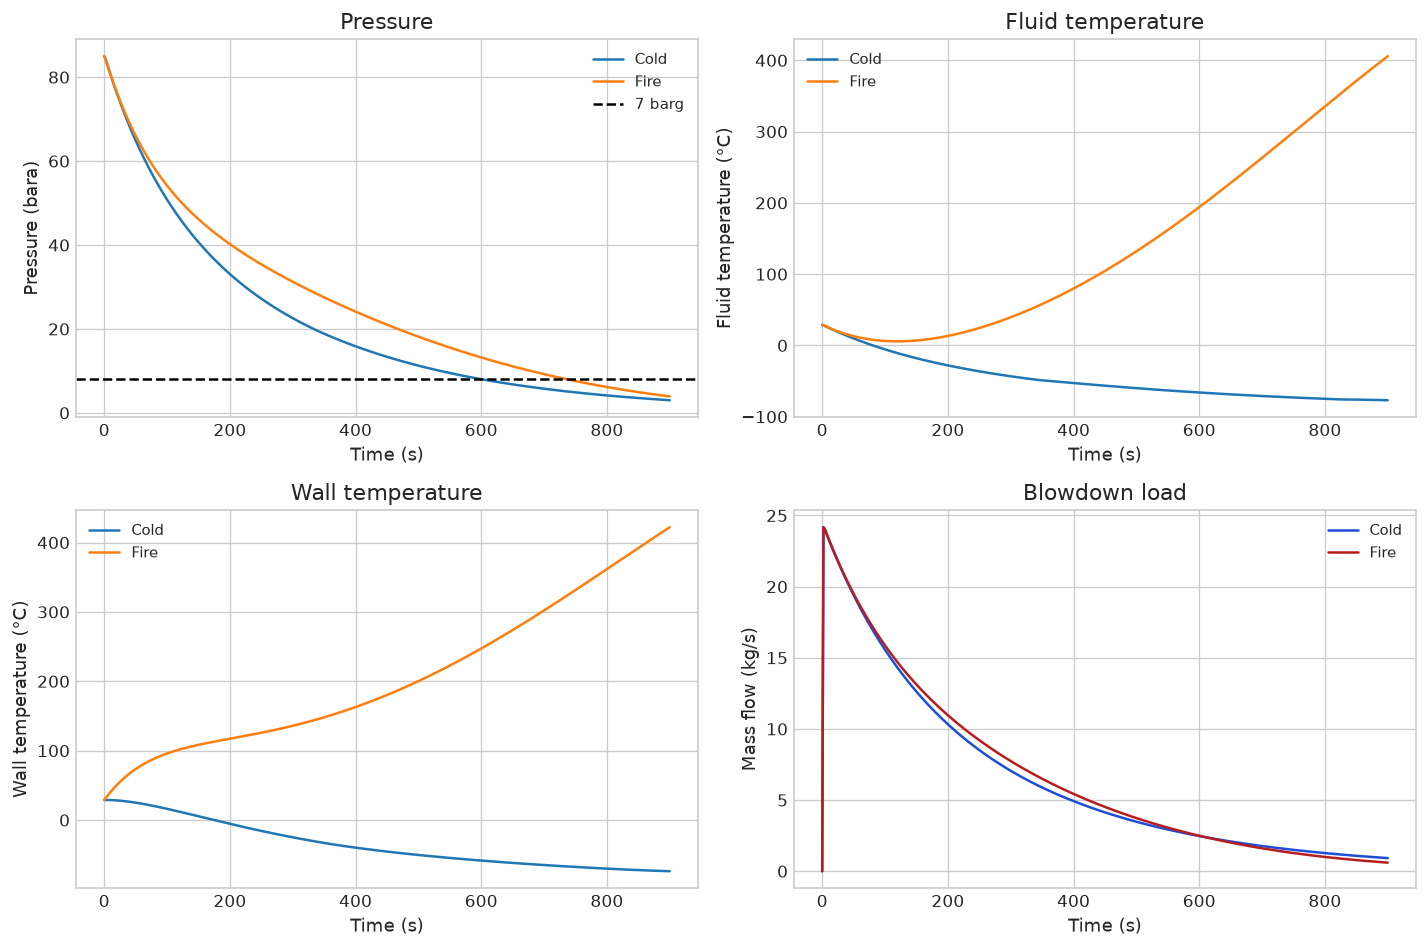

In [16]:
selected_diameter_mm = 45.0
cold_selected = cold_results[selected_diameter_mm]
fire_selected = run_blowdown(selected_diameter_mm, fire=True)


def result_frame(result):
    return pd.DataFrame(
        {
            "Time (s)": np.array(result.time, dtype=float),
            "Pressure (bara)": np.array(result.pressureBara, dtype=float),
            "Fluid temperature (°C)": (
                np.array(result.temperatureK, dtype=float) - 273.15
            ),
            "Wall temperature (°C)": (
                np.array(result.wallTempK, dtype=float) - 273.15
            ),
            "Mass flow (kg/s)": np.array(
                result.massFlowKgPerS,
                dtype=float,
            ),
        }
    )


cold_frame = result_frame(cold_selected)
fire_frame = result_frame(fire_selected)
selected_summary = pd.DataFrame(
    [
        [
            "Cold",
            cold_selected.timeToHalfPressure,
            cold_selected.timeTo7BargS,
            cold_selected.minFluidTemperatureK - 273.15,
            cold_selected.minWallTemperatureK - 273.15,
            cold_selected.maxWallTemperatureK - 273.15,
        ],
        [
            "Pool fire screening",
            fire_selected.timeToHalfPressure,
            fire_selected.timeTo7BargS,
            fire_selected.minFluidTemperatureK - 273.15,
            fire_selected.minWallTemperatureK - 273.15,
            fire_selected.maxWallTemperatureK - 273.15,
        ],
    ],
    columns=[
        "Case",
        "Time to half pressure (s)",
        "Time to 7 barg (s)",
        "Minimum fluid (°C)",
        "Minimum wall (°C)",
        "Maximum wall (°C)",
    ],
)
display(selected_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for frame, label, color in [
    (cold_frame, "Cold", "#1d4ed8"),
    (fire_frame, "Fire", "#b91c1c"),
]:
    axes[0, 0].plot(frame["Time (s)"], frame["Pressure (bara)"], label=label)
    axes[0, 1].plot(
        frame["Time (s)"],
        frame["Fluid temperature (°C)"],
        label=label,
    )
    axes[1, 0].plot(
        frame["Time (s)"],
        frame["Wall temperature (°C)"],
        label=label,
    )
    axes[1, 1].plot(
        frame["Time (s)"],
        frame["Mass flow (kg/s)"],
        label=label,
        color=color,
    )
axes[0, 0].axhline(8.0, color="black", linestyle="--", label="7 barg")
axes[0, 0].set(xlabel="Time (s)", ylabel="Pressure (bara)")
axes[0, 1].set(xlabel="Time (s)", ylabel="Fluid temperature (°C)")
axes[1, 0].set(xlabel="Time (s)", ylabel="Wall temperature (°C)")
axes[1, 1].set(xlabel="Time (s)", ylabel="Mass flow (kg/s)")
axes[0, 0].set_title("Pressure")
axes[0, 1].set_title("Fluid temperature")
axes[1, 0].set_title("Wall temperature")
axes[1, 1].set_title("Blowdown load")
for axis in axes.flat:
    axis.legend()
plt.tight_layout()
plt.show()

## Simultaneous blowdown and flare-header check

A second 30 m³ export scrubber starts at 95 bara and discharges through a 32 mm
orifice. NeqSim aligns both transient sources on a common time grid and evaluates
peak total mass flow, header velocity, and Mach number. Header gas properties are
initialized at the specified flare backpressure and temperature.

In [17]:
scrubber_result = run_blowdown(
    32.0,
    pressure_bara=95.0,
    temperature_k=313.15,
    volume_m3=30.0,
    wall_mass_kg=10_000.0,
    wall_area_m2=50.0,
)

header_fluid = gas_template.clone()
header_fluid.setPressure(1.5)
header_fluid.setTemperature(288.15)
header_operations = ns.thermodynamicoperations.ThermodynamicOperations(
    header_fluid
)
header_operations.TPflash()
header_fluid.initProperties()
header_molar_mass = float(header_fluid.getMolarMass())
header_gamma = float(
    header_fluid.getPhase(0).getCp()
    / header_fluid.getPhase(0).getCv()
)

header_rows = []
header_results = {}
for header_diameter_m in [0.40, 0.50, 0.60, 0.70, 0.80]:
    study = ns.process.safety.depressurization.MultiVesselBlowdownStudy()
    study.addSourceResult("V-101", cold_selected)
    study.addSourceResult("V-201 export scrubber", scrubber_result)
    study.setHeader(
        header_diameter_m,
        1.5,
        288.15,
        header_molar_mass,
        header_gamma,
    )
    study.setMaxAllowableMach(0.70)
    study.setGridStep(2.0)
    combined = study.run()
    header_results[header_diameter_m] = combined
    header_rows.append(
        [
            header_diameter_m,
            combined.getPeakTotalMassFlowKgPerS(),
            combined.getPeakTimeS(),
            combined.getHeaderVelocityMPerS(),
            combined.getHeaderMach(),
            combined.isHeaderMachAcceptable(),
        ]
    )
header_sensitivity = pd.DataFrame(
    header_rows,
    columns=[
        "Header diameter (m)",
        "Peak total flow (kg/s)",
        "Peak time (s)",
        "Header velocity (m/s)",
        "Header Mach",
        "Mach acceptable",
    ],
)
display(header_sensitivity)

,Header diameter (m),Peak total flow (kg/s),Peak time (s),Header velocity (m/s),Header Mach,Mach acceptable
0,0.4,37.419643,2.0,252.619528,0.624463,True
1,0.5,37.419643,2.0,161.676498,0.399656,True
2,0.6,37.419643,2.0,112.275346,0.277539,True
3,0.7,37.419643,2.0,82.488009,0.203906,True
4,0.8,37.419643,2.0,63.154882,0.156116,True


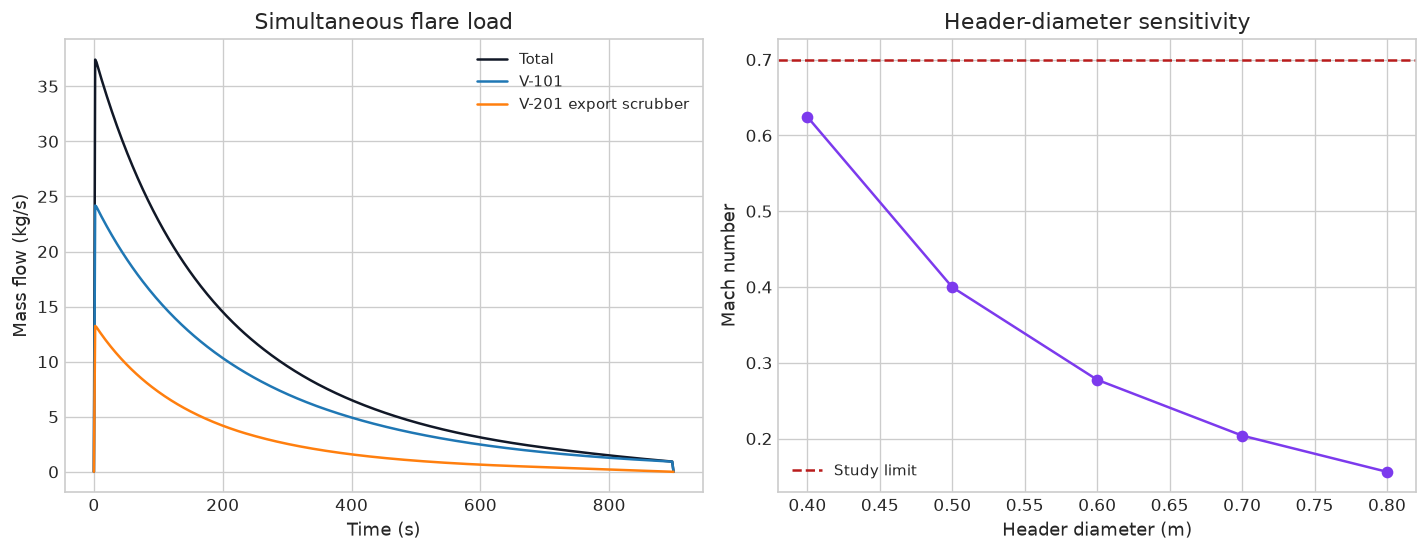

In [18]:
selected_header = header_results[0.60]
combined_time = np.array(selected_header.getTimeS(), dtype=float)
total_flow = np.array(
    selected_header.getTotalMassFlowKgPerS(),
    dtype=float,
)
source_map = selected_header.getSourceMassFlowKgPerS()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].plot(combined_time, total_flow, color="#111827", label="Total")
for source_name in source_map.keySet():
    source_flow = np.array(source_map.get(source_name), dtype=float)
    axes[0].plot(combined_time, source_flow, label=str(source_name))
axes[0].set(xlabel="Time (s)", ylabel="Mass flow (kg/s)")
axes[0].set_title("Simultaneous flare load")
axes[0].legend()

axes[1].plot(
    header_sensitivity["Header diameter (m)"],
    header_sensitivity["Header Mach"],
    marker="o",
    color="#7c3aed",
)
axes[1].axhline(0.70, color="#b91c1c", linestyle="--", label="Study limit")
axes[1].set(xlabel="Header diameter (m)", ylabel="Mach number")
axes[1].set_title("Header-diameter sensitivity")
axes[1].legend()
plt.tight_layout()
plt.show()

## Integrated acceptance matrix

In [19]:
selected_45 = blowdown_sweep.loc[
    blowdown_sweep["Orifice (mm)"] == 45.0
].iloc[0]
selected_60 = header_sensitivity.loc[
    header_sensitivity["Header diameter (m)"] == 0.60
].iloc[0]
acceptance = pd.DataFrame(
    [
        [
            "LOPA target",
            residual_frequency,
            f"≤ {target_frequency:.1e} per year",
            residual_frequency <= target_frequency,
        ],
        [
            "SIL verification",
            verification.getAchievedSIL(),
            f"≥ SIL {lopa.getRequiredAdditionalSIL()}",
            verification.getAchievedSIL()
            >= lopa.getRequiredAdditionalSIL(),
        ],
        [
            "Healthy response time",
            response_table.iloc[0]["Total (s)"],
            f"< {process_safety_time_s:.1f} s PST",
            bool(response_table.iloc[0]["Within PST"]),
        ],
        [
            "Healthy transient pressure",
            transient_summary.iloc[0]["Maximum pressure (bara)"],
            "< 100 bara MAWP",
            bool(transient_summary.iloc[0]["Below MAWP"]),
        ],
        [
            "45 mm time to half pressure",
            selected_45["Time to half pressure (s)"],
            "≤ 900 s screening criterion",
            selected_45["Time to half pressure (s)"] <= 900.0,
        ],
        [
            "45 mm VU flash fallbacks",
            selected_45["VU fallbacks"],
            "= 0",
            selected_45["VU fallbacks"] == 0,
        ],
        [
            "0.60 m header Mach",
            selected_60["Header Mach"],
            "≤ 0.70",
            bool(selected_60["Mach acceptable"]),
        ],
    ],
    columns=["Check", "Calculated", "Criterion", "Pass"],
)
display(acceptance)

,Check,Calculated,Criterion,Pass
0,LOPA target,8.143296e-07,≤ 1.0e-06 per year,True
1,SIL verification,3.000000e+00,≥ SIL 3,True
2,Healthy response time,8.100000e+00,< 90.3 s PST,True
3,Healthy transient pressure,8.283906e+01,< 100 bara MAWP,True
4,45 mm time to half pressure,1.398603e+02,≤ 900 s screening criterion,True
5,45 mm VU flash fallbacks,0.000000e+00,= 0,True
6,0.60 m header Mach,2.775392e-01,≤ 0.70,True


## Validation checks

In [20]:
checks = {
    "base_mass_balance_below_1e-6": (
        abs(mass_in - gas_mass - liquid_mass) / mass_in < 1.0e-6
    ),
    "required_sil_is_3": lopa.getRequiredAdditionalSIL() == 3,
    "hipps_pfd_in_sil3_band": 1.0e-4 <= hipps_pfd < 1.0e-3,
    "native_sil_verification_passes": verification.isSilAchieved(),
    "healthy_response_within_process_safety_time": bool(
        response_table.iloc[0]["Within PST"]
    ),
    "healthy_transient_below_mawp": bool(
        transient_summary.iloc[0]["Below MAWP"]
    ),
    "unavailable_hipps_reaches_mawp": not np.isnan(
        transient_summary.iloc[-1]["Time to MAWP (s)"]
    ),
    "cold_blowdown_has_no_vu_fallbacks": (
        blowdown_sweep["VU fallbacks"] == 0
    ).all(),
    "fire_result_has_no_vu_fallbacks": (
        fire_selected.vuFlashFallbackCount == 0
    ),
    "header_mach_is_finite": np.isfinite(
        header_sensitivity["Header Mach"]
    ).all(),
    "at_least_one_header_case_passes": (
        header_sensitivity["Mach acceptable"]
    ).any(),
}
validation = pd.DataFrame(
    [{"Check": key, "Pass": bool(value)} for key, value in checks.items()]
)
display(validation)
assert validation["Pass"].all(), validation

,Check,Pass
0,base_mass_balance_below_1e-6,True
1,required_sil_is_3,True
2,hipps_pfd_in_sil3_band,True
3,native_sil_verification_passes,True
4,healthy_response_within_process_safety_time,True
5,healthy_transient_below_mawp,True
6,unavailable_hipps_reaches_mawp,True
7,cold_blowdown_has_no_vu_fallbacks,True
8,fire_result_has_no_vu_fallbacks,True
9,header_mach_is_finite,True


## Interpretation and limitations

- The one-year proof interval achieves the synthetic SIL 3 target, while longer
  intervals expose sensitivity to common-cause and component assumptions.
- Healthy and one-sensor-unavailable cases remain far below MAWP in the screening
  pressure transient. A failed HIPPS reaches MAWP, so the PSV backup remains
  essential.
- A larger blowdown orifice reduces pressure faster but raises peak flare load and
  can deepen cold-temperature exposure.
- Fire heating routed to the wall is a screening scenario; this notebook has no
  wall-strength, rupture, jet-fire localization, passive-fire-protection, or
  escalation model.
- Header Mach is only one flare-network criterion. Project work must also check
  backpressure, acoustics, vibration, radiation, dispersion, liquid handling,
  dynamic interactions, and simultaneous-scenario credibility.

Suggested exercises are to change beta factors, proof-test coverage, closure time,
protected volume, MDMT, fire exposure, simultaneous-source assumptions, and the
header acceptance criterion.

## References

- [IEC 61511-1:2016](https://webstore.iec.ch/en/publication/24241)
- [IEC 61511-3:2016](https://webstore.iec.ch/en/publication/25480)
- [IEC 61511 series](https://webstore.iec.ch/en/publication/5527)
- [ISO 23251:2019](https://www.iso.org/standard/75144.html)
- [NeqSim repository](https://github.com/equinor/neqsim)